### Practice Deep Q-Network (DQN) with CarPole.

#### 1. RL loop: observe ---> act ---> receive reward ---> learn
#### 2. Q-Learning + function approximation(neural network)
#### 3. Experience reply buffer
#### 4. Epsilon-greedy exploration
#### 5. Target network for stability

In [12]:
# %pip install gymnasium torch numpy matplotlib

#### Simple DQN for CartPole-v1

In [13]:
import gymnasium as gym
import torch.optim as optim
import torch.nn as nn
import numpy as np
import random
import collections
import torch
import math
import time
import matplotlib.pyplot as plt

In [14]:
# Device Setup
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [15]:
# ---------- Hyperparameters ----------
ENV_NAME = "CartPole-v1"
SEED = 42
GAMMA = 0.99
LR = 1e-4   # Reduced learning rate   #5e-4   #1e-3
BATCH_SIZE = 128 # Slightly smaller batch  #64
BUFFER_SIZE = 20000 #10000
MIN_REPLAY_SIZE = 1000  #500
EPS_START = 1.0
EPS_END = 0.01  # Lower final epsilon  #0.02
EPS_DECAY = 10000   # Much slower decay  #5000    #4000  #2000    # decay steps (controls speed of annealing)
TARGET_UPDATE_FREQ = 100    # CRITICAL: Much more frequent!   #2000   #1000  # steps
MAX_STEPS = 50000   # increased training steps  #20000
PRINT_EVERY = 500
HIDDEN = 128

In [16]:
# ---------- Environment ----------
env = gym.make(ENV_NAME, render_mode="human")        # Creates the CartPole environment
env.reset(seed=SEED)            
# Sets the seed for the environment's random number generator
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Gets size of state and action from openAI gym environment
obs_size = env.observation_space.shape[0]
n_actions = env.action_space.n

print(env.observation_space)
print(obs_size, n_actions) 

Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
4 2


In [17]:
# ---------- Network ----------
class QNetwork(nn.Module):
    def __init__(self, obs_size, n_actions, hidden=HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )

    def forward(self, x):
        return self.net(x)

# Create networks
policy_net = QNetwork(obs_size, n_actions).to(device)   # the main neural net that we train
target_net = QNetwork(obs_size, n_actions).to(device)   # a slowly updated copy  that stabilizes learning
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()       # puts the target network in evaluation mode(disables dropout, batchnorm, etc)

# Optimizer and loss function
optimizer = optim.Adam(policy_net.parameters(), lr=LR)
loss_fn = nn.MSELoss() 

In [18]:
# ---------- Replay Buffer ----------
Transition = collections.namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = collections.deque(maxlen=capacity)    # (double-ended queue) that automatically drops old entries when full
    
    def push(self, *args):
        self.buffer.append(Transition(*args))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states = torch.tensor(np.vstack([b.state for b in batch]), dtype=torch.float32, device=device)
        actions = torch.tensor([b.action for b in batch], dtype=torch.int64, device=device).unsqueeze(1)
        rewards = torch.tensor([b.reward for b in batch], dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.vstack([b.next_state for b in batch]), dtype=torch.float32, device=device)
        dones = torch.tensor([b.done for b in batch], dtype=torch.float32, device=device).unsqueeze(1)
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.buffer)
    
replay = ReplayBuffer(BUFFER_SIZE)
    

In [19]:
# ---------- Helpers ----------
def select_action(state, steps_done):
    # epsilon greedy policy with exponential decay
    eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1.0 * steps_done / EPS_DECAY)
    if random.random() < eps_threshold:
        return random.randrange(n_actions), eps_threshold
    else:
        state_v = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            q_vals = policy_net(state_v)
            return int(q_vals.argmax().item()), eps_threshold
        
def compute_loss(batch):
    states, actions, rewards, next_states, dones = batch
    # current Q values
    q_values = policy_net(states).gather(1, actions) # shape [batch, 1]
    # next Q values from target network (double DQN would use policy_net for argmax, but we keep vanilla DQN here)
    with torch.no_grad():
        next_q_values = target_net(next_states).max(1)[0].unsqueeze(1) 
        # Using Bellman equation to compute target Q values
        target = rewards + (1 - dones) * GAMMA * next_q_values
    loss = loss_fn(q_values, target)
    return loss

In [20]:
# ---------- Pre-fill replay buffer with random actions ----------
state, _ = env.reset(seed=SEED)
for _ in range(MIN_REPLAY_SIZE):
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    replay.push(state, action, reward, next_state, done)
    if done:
        state, _ = env.reset()
    else:
        state = next_state

print("Filled replay buffer with", len(replay), "transitions")

Filled replay buffer with 1000 transitions


In [21]:
# ---------- Training Loop ----------
steps_done = 0
episode_rewards = []
state, _ = env.reset()
episode_reward = 0.0
start_time = time.time()

while steps_done < MAX_STEPS:
    # 1. Select action using epsilon-greedy policy
    action, eps_threshold = select_action(state, steps_done)
    # 2. Take action in environment
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    replay.push(state, action, reward, next_state, done)
    state = next_state
    episode_reward += reward
    steps_done += 1
    
    # sample and learn
    if len(replay) >= BATCH_SIZE:
        batch = replay.sample(BATCH_SIZE)
        loss = compute_loss(batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
        optimizer.step()

    # update target network
    if steps_done % TARGET_UPDATE_FREQ == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if steps_done % PRINT_EVERY == 0:
        print(f"Step {steps_done}\tEpisode {len(episode_rewards)}\tLast reward {episode_reward:.2f}\tMean10 {mean10:.2f}\t Epsilon {eps_threshold:.2f}")

    if done:
        episode_rewards.append(episode_reward)
        if len(episode_rewards) % 10 == 0:
            mean10 = sum(episode_rewards[-10:]) / 10
        else:
            mean10 = sum(episode_rewards[-min(len(episode_rewards), 10):]) / max(1, min(len(episode_rewards), 10))
         
        state, _ = env.reset()
        episode_reward = 0.0
    
    # time.sleep(0.02)    # slow down for rendering

# Done Training
duration = time.time() - start_time
print("Training finished in {:.1f}s, steps {}, episodes{}, avg reward {:.2f}".format(
    duration, steps_done, len(episode_rewards), sum(episode_rewards)/max(1,len(episode_rewards))))

# Save the model
torch.save(policy_net.state_dict(), "dqn_cartpole_model.pth")
print("Saved model as dqn_cartpole_model.pth")
env.close()

Step 500	Episode 26	Last reward 14.00	Mean10 14.30	 Epsilon 0.95
Step 1000	Episode 48	Last reward 17.00	Mean10 25.80	 Epsilon 0.91
Step 1500	Episode 68	Last reward 10.00	Mean10 22.20	 Epsilon 0.86
Step 2000	Episode 86	Last reward 16.00	Mean10 22.30	 Epsilon 0.82
Step 2500	Episode 102	Last reward 1.00	Mean10 38.70	 Epsilon 0.78
Step 3000	Episode 116	Last reward 20.00	Mean10 35.10	 Epsilon 0.74
Step 3500	Episode 122	Last reward 84.00	Mean10 55.10	 Epsilon 0.71
Step 4000	Episode 127	Last reward 103.00	Mean10 87.60	 Epsilon 0.67
Step 4500	Episode 134	Last reward 23.00	Mean10 91.30	 Epsilon 0.64
Step 5000	Episode 138	Last reward 119.00	Mean10 86.80	 Epsilon 0.61
Step 5500	Episode 145	Last reward 48.00	Mean10 85.00	 Epsilon 0.58
Step 6000	Episode 148	Last reward 50.00	Mean10 106.90	 Epsilon 0.55
Step 6500	Episode 152	Last reward 61.00	Mean10 122.80	 Epsilon 0.53
Step 7000	Episode 156	Last reward 48.00	Mean10 137.50	 Epsilon 0.50
Step 7500	Episode 159	Last reward 55.00	Mean10 133.70	 Epsilon 

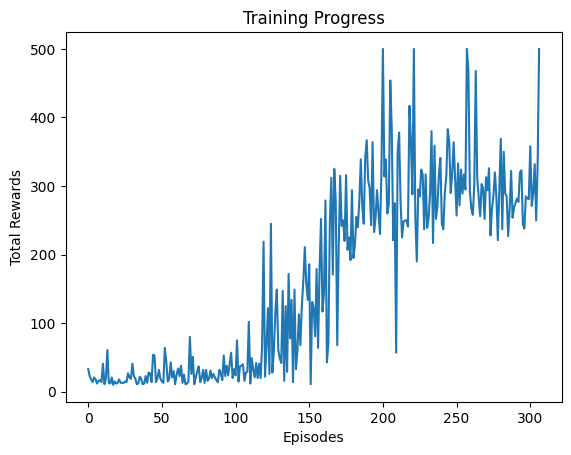

In [22]:
plt.plot(episode_rewards)
plt.xlabel('Episodes')
plt.ylabel('Total Rewards')
plt.title('Training Progress')
plt.show()